# Exploratory Data Analysis - Fraud Data
This notebook performs the Exploratory Data Analysis (EDA) for the transaction fraud dataset, integrating IP addresses with countries to analyze fraud patterns by geography.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src directory to path
sys.path.append(os.path.abspath('../'))
from src.data_preprocessor import load_data, clean_fraud_data, merge_geolocation

# Configure plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
os.makedirs('../reports/figures', exist_ok=True)

## 1. Load and Preprocess Data
We load the raw datasets and perform data cleaning and geolocation range-based lookup.

In [2]:
# Load raw data
fraud_raw = load_data('../data/raw/Fraud_Data.csv')
ip_raw = load_data('../data/raw/IpAddress_to_Country.csv')

# Clean and merge geolocation
fraud_cleaned = clean_fraud_data(fraud_raw)
fraud = merge_geolocation(fraud_cleaned, ip_raw)

print('Merged data shape:', fraud.shape)
fraud.head()

Merged data shape: (151112, 12)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Unknown
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States


## 2. Univariate Distributions
Let's visualize the distribution of key variables: Class, Purchase Value, Age, Source, Browser, and Sex.

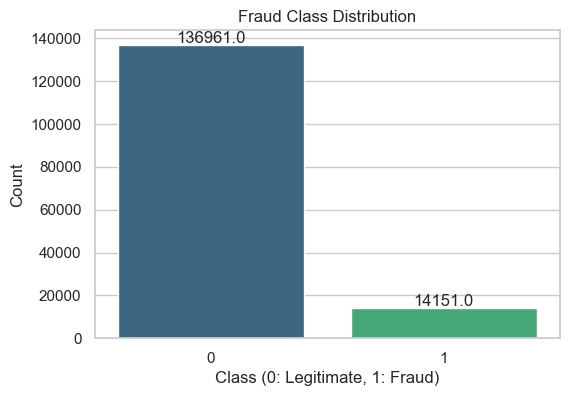

In [3]:
# Class Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='class', data=fraud, hue='class', palette='viridis', legend=False)
plt.title('Fraud Class Distribution')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig('../reports/figures/fraud_class_dist.png', bbox_inches='tight')
plt.show()

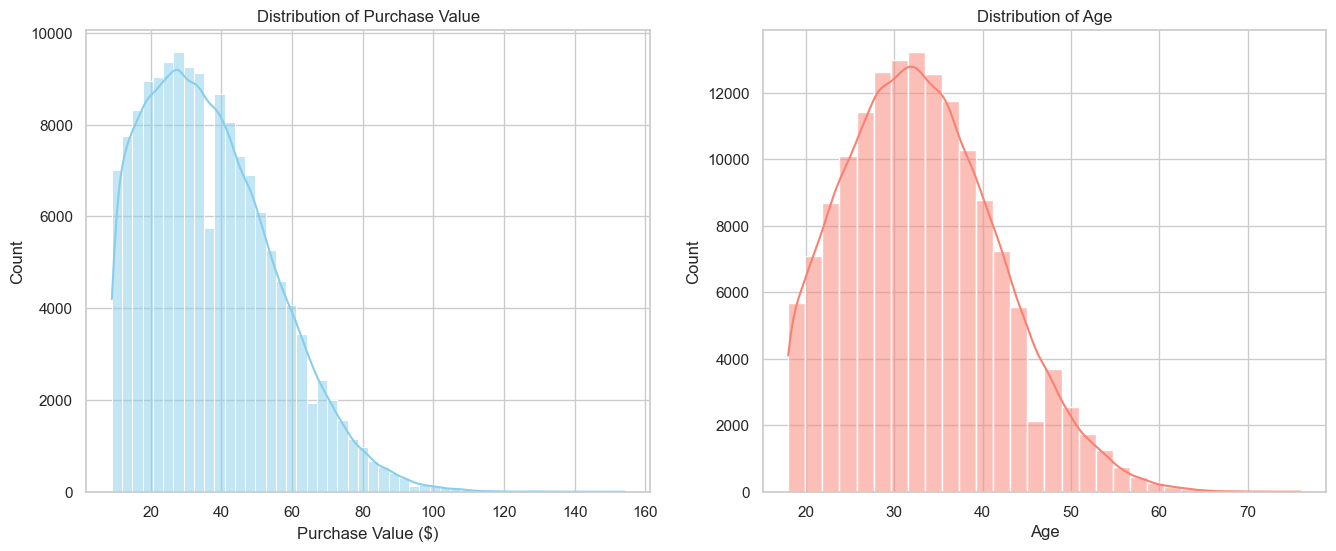

In [4]:
# Purchase Value & Age Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(fraud['purchase_value'], kde=True, bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Purchase Value')
axes[0].set_xlabel('Purchase Value ($)')

sns.histplot(fraud['age'], kde=True, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Age')
axes[1].set_xlabel('Age')

plt.savefig('../reports/figures/purchase_value_age_dist.png', bbox_inches='tight')
plt.show()

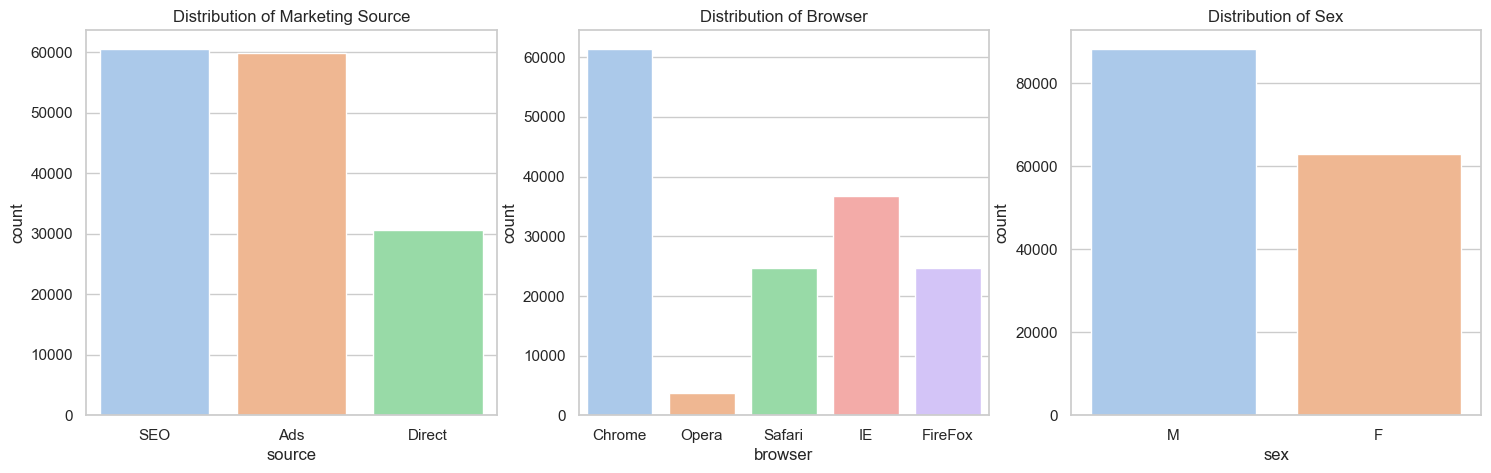

In [5]:
# Source, Browser, and Sex Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='source', data=fraud, ax=axes[0], hue='source', palette='pastel', legend=False)
axes[0].set_title('Distribution of Marketing Source')

sns.countplot(x='browser', data=fraud, ax=axes[1], hue='browser', palette='pastel', legend=False)
axes[1].set_title('Distribution of Browser')

sns.countplot(x='sex', data=fraud, ax=axes[2], hue='sex', palette='pastel', legend=False)
axes[2].set_title('Distribution of Sex')

plt.savefig('../reports/figures/categoricals_dist.png', bbox_inches='tight')
plt.show()

## 3. Bivariate Relationships
Let's explore how purchase value, age, browser, source, and country relate to the target class (fraud).

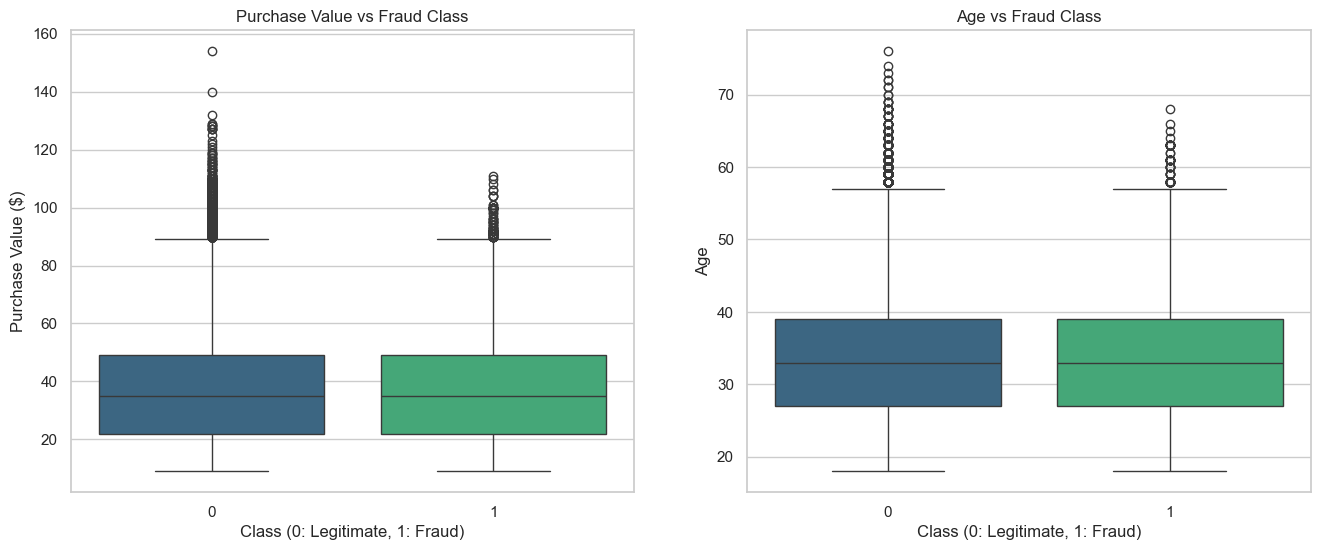

In [6]:
# Purchase Value and Age vs Class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='class', y='purchase_value', data=fraud, ax=axes[0], hue='class', palette='viridis', legend=False)
axes[0].set_title('Purchase Value vs Fraud Class')
axes[0].set_xlabel('Class (0: Legitimate, 1: Fraud)')
axes[0].set_ylabel('Purchase Value ($)')

sns.boxplot(x='class', y='age', data=fraud, ax=axes[1], hue='class', palette='viridis', legend=False)
axes[1].set_title('Age vs Fraud Class')
axes[1].set_xlabel('Class (0: Legitimate, 1: Fraud)')
axes[1].set_ylabel('Age')

plt.savefig('../reports/figures/bivariate_continuous.png', bbox_inches='tight')
plt.show()

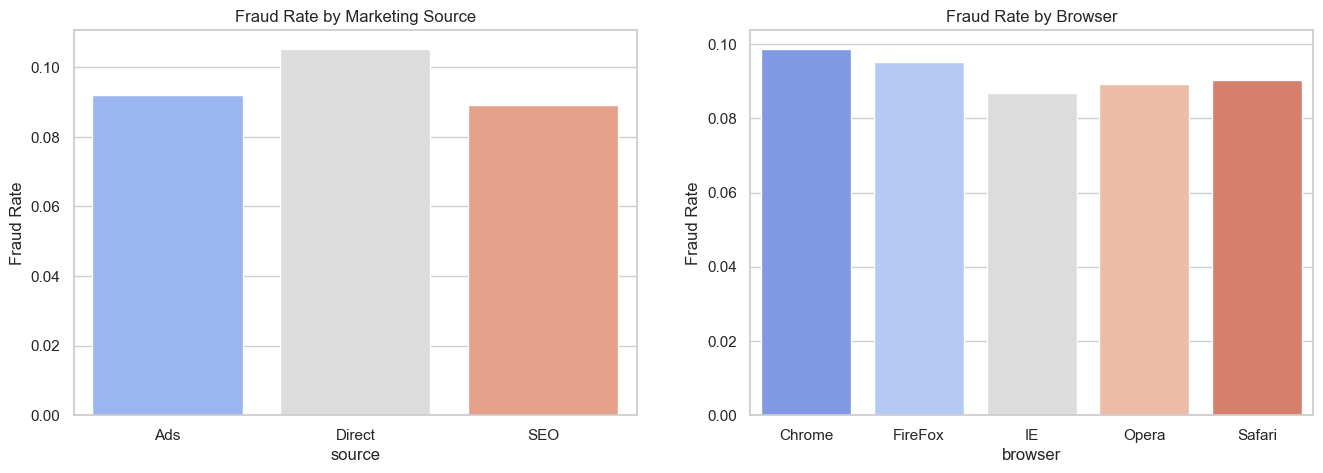

In [7]:
# Fraud rates across Source and Browser
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

source_fraud = fraud.groupby('source')['class'].mean().reset_index()
sns.barplot(x='source', y='class', data=source_fraud, ax=axes[0], hue='source', palette='coolwarm', legend=False)
axes[0].set_title('Fraud Rate by Marketing Source')
axes[0].set_ylabel('Fraud Rate')

browser_fraud = fraud.groupby('browser')['class'].mean().reset_index()
sns.barplot(x='browser', y='class', data=browser_fraud, ax=axes[1], hue='browser', palette='coolwarm', legend=False)
axes[1].set_title('Fraud Rate by Browser')
axes[1].set_ylabel('Fraud Rate')

plt.savefig('../reports/figures/bivariate_categoricals.png', bbox_inches='tight')
plt.show()

## 4. Geolocation Analysis
Let's analyze fraud rates by country to identify geographic patterns.

Top 15 Countries by Transaction Volume:
country
United States         58049
Unknown               21966
China                 12038
Japan                  7306
United Kingdom         4490
Korea Republic of      4162
Germany                3646
France                 3161
Canada                 2975
Brazil                 2961
Italy                  1944
Australia              1844
Netherlands            1680
Russian Federation     1616
India                  1310
Name: count, dtype: int64


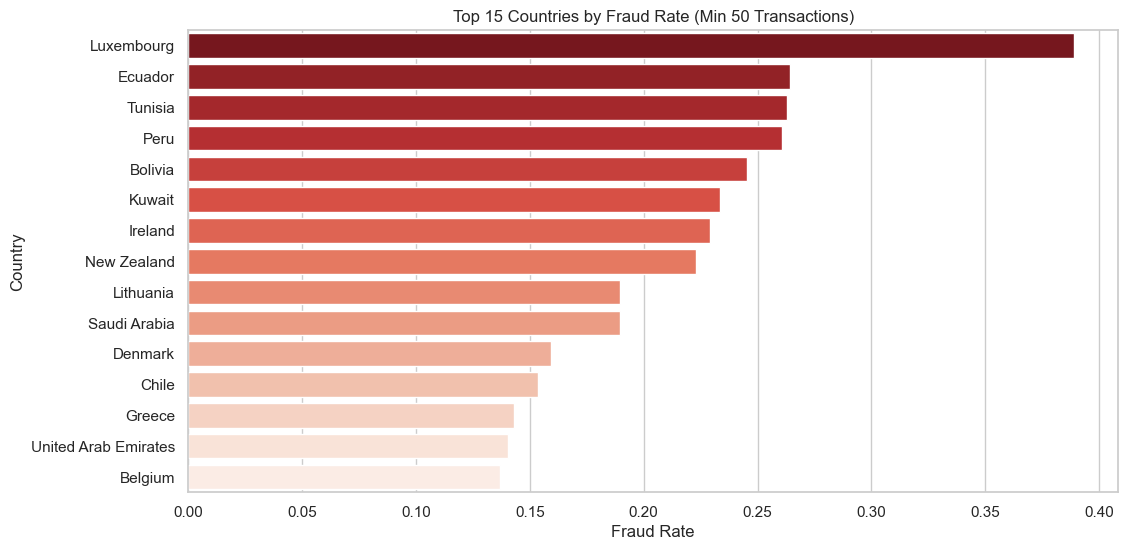

In [8]:
# Top Countries by Transaction Volume
country_counts = fraud['country'].value_counts()
print('Top 15 Countries by Transaction Volume:')
print(country_counts.head(15))

# Calculate fraud rates per country for countries with at least 50 transactions
country_stats = fraud.groupby('country').agg(
    total_transactions=('class', 'count'),
    fraud_transactions=('class', 'sum'),
    fraud_rate=('class', 'mean')
).reset_index()

top_fraud_countries = country_stats[country_stats['total_transactions'] >= 50].sort_values('fraud_rate', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='fraud_rate', y='country', data=top_fraud_countries.head(15), hue='country', palette='Reds_r', legend=False)
plt.title('Top 15 Countries by Fraud Rate (Min 50 Transactions)')
plt.xlabel('Fraud Rate')
plt.ylabel('Country')
plt.savefig('../reports/figures/country_fraud_rates.png', bbox_inches='tight')
plt.show()

## 5. Class Imbalance Quantification
Let's measure the class imbalance in details.

In [9]:
legit_count = (fraud['class'] == 0).sum()
fraud_count = (fraud['class'] == 1).sum()
total = len(fraud)

print(f'Legitimate transactions: {legit_count} ({legit_count/total*100:.2f}%)')
print(f'Fraudulent transactions: {fraud_count} ({fraud_count/total*100:.2f}%)')
print(f'Class ratio (Legit/Fraud): {legit_count/fraud_count:.2f}:1')

Legitimate transactions: 136961 (90.64%)
Fraudulent transactions: 14151 (9.36%)
Class ratio (Legit/Fraud): 9.68:1


## Summary of EDA Insights (Fraud Data)
1. **Class Imbalance**: The dataset is heavily imbalanced, with only 9.36% of transactions classified as fraud. Modeling will require class balancing techniques like SMOTE or undersampling.
2. **Purchase Value and Age**: The distributions of purchase value and age are highly similar between legitimate and fraudulent transactions. Univariate differences are minimal, suggesting combinations of features or other dimensions (like velocity) will drive detection.
3. **Browsers & Sources**: Chrome and Ads represent the largest volumes, but Chrome/IE/FireFox/Safari share similar fraud rates (~9-10%), while Opera has slightly lower rates. Marketing source has negligible impact on fraud rates.
4. **Geography**: The United States, China, and Japan represent the highest transaction volume. However, small-volume countries or specific allocations (like select European or Asian nations) show elevated fraud rates. IP addresses mapping to 'Unknown' (missing from map) also exhibit standard fraud rates.